# DragonNet: JAX vs TF Benchmark

Compares the JAX (`flax.nnx`) and TF (Keras) DragonNet implementations on the
IHDP semi-synthetic dataset using ATE, MAE, AUUC, and wall-clock training time.

Reference: Shi, Blei & Veitch (2019) — https://arxiv.org/pdf/1906.02120.pdf

## Installation

**TF backend:**
```
pip install tensorflow
```

**JAX backend:**
```
pip install "causalml[jax]"
# or: uv pip install jax flax optax orbax-checkpoint
```

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import time
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.metrics import mean_absolute_error

from causalml.metrics import auuc_score, plot_gain

# fmt: off
%matplotlib inline
warnings.filterwarnings("ignore")
plt.style.use("fivethirtyeight")
sns.set_palette("Paired")
plt.rcParams["figure.figsize"] = (12, 8)
# fmt: on

try:
    from causalml.inference.tf import DragonNet as TFDragonNet

    HAS_TF = True
except ImportError:
    HAS_TF = False
    print("[INFO] tensorflow not installed — TF DragonNet will be skipped.")

try:
    from causalml.inference.jax import DragonNet as JAXDragonNet

    HAS_JAX = True
except ImportError:
    HAS_JAX = False
    print("[INFO] jax/flax not installed — JAX DragonNet will be skipped.")

## IHDP Dataset

Semi-synthetic dataset from Hill (2011), used in the original DragonNet paper.
747 observations from the Infant Health and Development Program (IHDP) study.
We use one realisation (`ihdp_npci_3.csv`) to reproduce the notebook benchmark.

In [3]:
DATA_PATH = os.path.join(os.path.dirname(os.path.abspath("__file__")), "data", "ihdp_npci_3.csv")

df = pd.read_csv(DATA_PATH, header=None)
cols = ["treatment", "y_factual", "y_cfactual", "mu0", "mu1"] + [
    f"x{i}" for i in range(1, 26)
]
df.columns = cols

X = df.loc[:, "x1":].values
treatment = df["treatment"].values
y = df["y_factual"].values
tau = df.apply(
    lambda d: d["y_factual"] - d["y_cfactual"]
    if d["treatment"] == 1
    else d["y_cfactual"] - d["y_factual"],
    axis=1,
).values

print(f"n={len(y)},  actual ATE = {tau.mean():.4f}")
df.head()

n=747,  actual ATE = 4.0989


,treatment,y_factual,y_cfactual,mu0,mu1,x1,x2,x3,x4,x5,...,x16,x17,x18,x19,x20,x21,x22,x23,x24,x25
0,1,5.931652,3.500591,2.253801,7.136441,-0.528603,-0.343455,1.128554,0.161703,-0.316603,...,1,1,1,1,0,0,0,0,0,0
1,0,2.175966,5.952101,1.257592,6.553022,-1.736945,-1.802002,0.383828,2.244320,-0.629189,...,1,1,1,1,0,0,0,0,0,0
2,0,2.180294,7.175734,2.384100,7.192645,-0.807451,-0.202946,-0.360898,-0.879606,0.808706,...,1,0,1,1,0,0,0,0,0,0
3,0,3.587662,7.787537,4.009365,7.712456,0.390083,0.596582,-1.850350,-0.879606,-0.004017,...,1,0,1,1,0,0,0,0,0,0
4,0,2.372618,5.461871,2.481631,7.232739,-1.045229,-0.602710,0.011465,0.161703,0.683672,...,1,1,1,1,0,0,0,0,0,0


## Train DragonNet

In [4]:
SEED = 42
HYPERPARAMS = dict(neurons_per_layer=200, targeted_reg=True, verbose=False)

np.random.seed(SEED)

results = {}  # label -> {"ite": array, "train_time": float}

for label, cls, available in [
    ("TF DragonNet", TFDragonNet if HAS_TF else None, HAS_TF),
    ("JAX DragonNet", JAXDragonNet if HAS_JAX else None, HAS_JAX),
]:
    if not available:
        print(f"[{label}] skipped (backend not installed).")
        continue
    print(f"[{label}] fitting...")
    model = cls(**HYPERPARAMS)
    t0 = time.perf_counter()
    model.fit(X, treatment, y)
    train_time = time.perf_counter() - t0
    ite = model.predict_tau(X).ravel()
    results[label] = {"ite": ite, "train_time": train_time}
    print(f"[{label}] done — ATE={ite.mean():.4f},  train time={train_time:.2f}s")

[TF DragonNet] fitting...
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
[TF DragonNet] done — ATE=3.9991,  train time=4.46s
[JAX DragonNet] fitting...
[JAX DragonNet] done — ATE=3.5613,  train time=3.07s


## Results

In [5]:
# Build df_preds following the same convention as dragonnet_example.ipynb:
# model columns + reserved columns tau / w / y
preds_data = {label: v["ite"] for label, v in results.items()}
preds_data.update({"tau": tau, "w": treatment, "y": y})
df_preds = pd.DataFrame(preds_data)

rows = []
for label, v in results.items():
    ite = v["ite"]
    rows.append(
        {
            "ATE": float(ite.mean()),
            "Actual ATE": float(tau.mean()),
            "MAE": float(mean_absolute_error(tau, ite)),
            "Train time (s)": float(v["train_time"]),
        }
    )

df_result = pd.DataFrame(rows, index=list(results.keys()))
df_result["AUUC"] = auuc_score(
    df_preds, outcome_col="y", treatment_col="w", treatment_effect_col="tau"
)

df_result

,ATE,Actual ATE,MAE,Train time (s),AUUC
TF DragonNet,3.999130,4.098887,1.180591,4.464176,0.554458
JAX DragonNet,3.561278,4.098887,1.267259,3.065250,0.557676


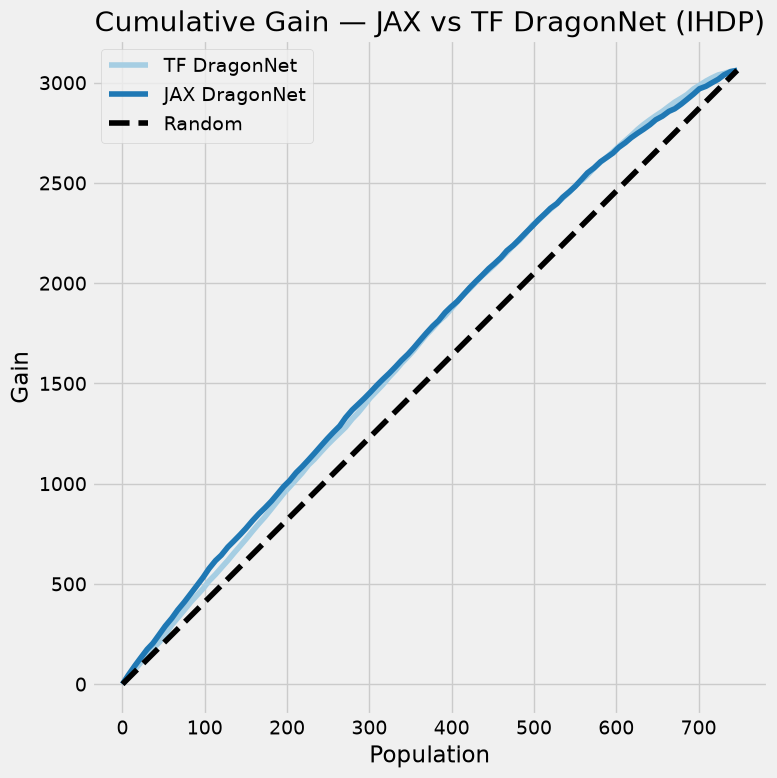

In [6]:
plot_gain(df_preds, outcome_col="y", treatment_col="w", treatment_effect_col="tau")
plt.title("Cumulative Gain — JAX vs TF DragonNet (IHDP)")
plt.tight_layout()
plt.show()

> **Note on training time:** JAX train time includes one-time JIT compilation
> on the first mini-batch. TF time includes Keras graph building overhead.
> Both are measured end-to-end from `fit()` call to return.